# Notebook 04 — Feature Selection (train-only statistics)
### Credit Risk — Probability of Default (PD) Scorecard | Stage 5

---

## What this notebook does

Narrows the 98 columns from Stage 4 down to the final modelling feature sets,
using the blueprint's layered approach:

1. **Information Value** filter — drop IV < 0.02 ("useless" band)
2. **Pairwise correlation** filter — drop one of each pair above |0.85|, keeping the higher-IV member
3. **Mutual Information** cross-check — an independent, non-linear second opinion
4. **VIF** (Variance Inflation Factor) — multi-feature collinearity, producing a reduced set for Logistic Regression specifically

**Outputs:** `features_selected_general.csv` (tree models), `features_selected_lr.csv`
(Logistic Regression, VIF-reduced), and `train_test_split_ids.csv` (the frozen
80/20 split used by every later notebook).

## Why the train/test split happens FIRST in this notebook

Feature selection uses `TARGET`. If IV, correlation, MI, and VIF are computed
on **all** 307,511 rows, the labels of the future test set influence which
features survive — a form of **selection leakage** that makes the final test
score slightly optimistic. The professionally correct order is:

> **split → select on train only → model → touch test once at the end.**

So this notebook creates the project's single stratified 80/20 split up front
(`random_state=42`), **freezes it to disk**, and computes every selection
statistic on the 246k training rows only. Notebook 05 loads the same frozen
split — the test set stays untouched until final evaluation.

> Run from the project root, top to bottom (`Kernel → Restart & Run All`).
> Requires `utils.py` in the project root.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import utils
from utils import (DATA_PATH, FIG_PATH, C_RED, C_BLUE, C_GREEN, C_GREY,
                   RANDOM_STATE, save_show, barh_topn, is_text_column)
utils.setup()

df = pd.read_csv(DATA_PATH + "model_ready_features.csv")
print(f"Input shape: {df.shape}")
assert df.shape == (307511, 98), "Unexpected input - re-run notebook 03 first"



Input shape: (307511, 98)


## 4.1 Create and freeze the project's train/test split

In [5]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    stratify=df['TARGET'],
    random_state=RANDOM_STATE,
)

df_train = df.loc[train_idx]

print(f"Train: {len(train_idx):,} rows | default rate {df_train['TARGET'].mean()*100:.2f}%")
print(f"Test : {len(test_idx):,} rows | default rate {df.loc[test_idx, 'TARGET'].mean()*100:.2f}%")

# Freeze the split to disk - notebook 05 loads THESE ids, it never re-splits
split_df = pd.DataFrame({'SK_ID_CURR': df['SK_ID_CURR'],
                         'SPLIT': np.where(df.index.isin(train_idx), 'train', 'test')})
split_df.to_csv(DATA_PATH + "train_test_split_ids.csv", index=False)
print(f"\nSplit frozen to train_test_split_ids.csv "
      f"({(split_df['SPLIT']=='train').sum():,} train / {(split_df['SPLIT']=='test').sum():,} test)")

print("\nEvery statistic below is computed on df_train ONLY.")

Train: 246,008 rows | default rate 8.07%
Test : 61,503 rows | default rate 8.07%

Split frozen to train_test_split_ids.csv (246,008 train / 61,503 test)

Every statistic below is computed on df_train ONLY.


**Stratification confirmed** — both halves carry the same 8.07% default rate,
so the imbalance the models must handle is identical in training and evaluation.

## 4.2 Layer 1 — Information Value

IV measures how well a feature separates defaulters from non-defaulters after
optimal binning. Interpretation bands: <0.02 useless · 0.02–0.1 weak ·
0.1–0.3 medium · 0.3–0.5 strong · >0.5 suspicious (check for leakage).

### The dtype bug (found, diagnosed, fixed — the story in short)

The first version of the IV loop routed columns with
`df[col].dtype == 'object'` to categorical binning. In this pandas version
some text columns report dtype **`str`**, not `object` — so all 10 categorical
columns silently went down the *numerical* path, crashed inside OptimalBinning,
and a bare `try/except` swallowed the crashes as `NaN` IV. It was caught
because the "failed" list included `NAME_EDUCATION_TYPE` — which EDA had proven
clearly predictive. **A metrics result that contradicts your own earlier
evidence is a bug alarm, not a finding.** Demonstration of the root cause:

In [6]:
col = 'NAME_EDUCATION_TYPE'
print(f"dtype of {col}: {df_train[col].dtype}")
print(f"naive check  (dtype == 'object')          : {df_train[col].dtype == 'object'}")
print(f"robust check (utils.is_text_column)        : {is_text_column(df_train[col])}")

dtype of NAME_EDUCATION_TYPE: str
naive check  (dtype == 'object')          : False
robust check (utils.is_text_column)        : True


The corrected loop below uses the robust check, and errors are *recorded*
instead of silently swallowed — the two lessons from the bug, encoded.

In [7]:
from optbinning import OptimalBinning

exclude_cols = ['SK_ID_CURR', 'TARGET']
feature_cols = [c for c in df.columns if c not in exclude_cols]

iv_results = []
y = df_train['TARGET'].values

for col in feature_cols:
    try:
        x = df_train[col].values
        kind = "categorical" if is_text_column(df_train[col]) else "numerical"
        optb = OptimalBinning(name=col, dtype=kind, solver="cp")
        optb.fit(x, y)
        iv = optb.binning_table.build()['IV'].values[-1]
        iv_results.append({'feature': col, 'IV': float(iv), 'error': None})
    except Exception as e:                      # record, never swallow
        iv_results.append({'feature': col, 'IV': np.nan, 'error': str(e)[:80]})

iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False).reset_index(drop=True)

failed = iv_df[iv_df['IV'].isna()]
print(f"Features scored: {iv_df['IV'].notna().sum()} / {len(feature_cols)}"
      f" | failed: {len(failed)}")
if len(failed):
    print(failed[['feature', 'error']].to_string(index=False))
print()
print(iv_df.head(20)[['feature', 'IV']].to_string(index=False))

Features scored: 96 / 96 | failed: 0

                    feature   IV
            EXT_SOURCE_MEAN 0.63
             EXT_SOURCE_SUM 0.44
               EXT_SOURCE_3 0.34
               EXT_SOURCE_2 0.32
               EXT_SOURCE_1 0.15
              DAYS_EMPLOYED 0.12
          DEBT_CREDIT_RATIO 0.11
                CREDIT_TERM 0.11
            AMT_GOODS_PRICE 0.09
                 DAYS_BIRTH 0.09
                    AGE_INT 0.09
            OCCUPATION_TYPE 0.08
   CREDIT_GOODS_PRICE_RATIO 0.07
          ORGANIZATION_TYPE 0.06
     RECENT_AVG_UTILIZATION 0.06
                 AMT_CREDIT 0.06
           NAME_INCOME_TYPE 0.06
              REFUSED_COUNT 0.05
REGION_RATING_CLIENT_W_CITY 0.05
       REGION_RATING_CLIENT 0.05


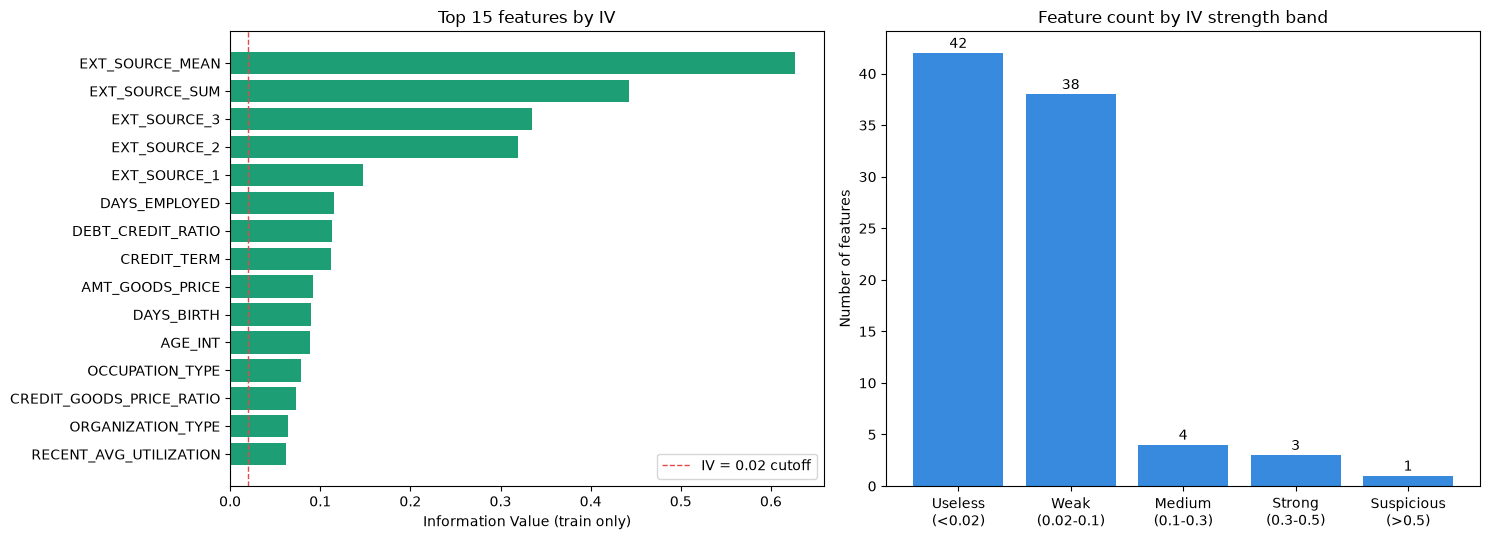

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

top15 = iv_df.head(15).sort_values('IV')
axes[0].barh(top15['feature'], top15['IV'], color=C_GREEN)
axes[0].axvline(x=0.02, color=C_RED, linestyle='--', linewidth=1, label='IV = 0.02 cutoff')
axes[0].set_xlabel('Information Value (train only)')
axes[0].set_title('Top 15 features by IV')
axes[0].legend()

bins = [0, 0.02, 0.1, 0.3, 0.5, 1.0]
labels = ['Useless\n(<0.02)', 'Weak\n(0.02-0.1)', 'Medium\n(0.1-0.3)',
          'Strong\n(0.3-0.5)', 'Suspicious\n(>0.5)']
band_counts = pd.cut(iv_df['IV'], bins=bins, labels=labels).value_counts().reindex(labels)
axes[1].bar(band_counts.index, band_counts.values, color=C_BLUE)
for i, v in enumerate(band_counts.values):
    axes[1].text(i, v + 0.5, str(int(v)), ha='center')
axes[1].set_ylabel('Number of features')
axes[1].set_title('Feature count by IV strength band')

save_show("04_iv_overview.png")

**Reading the IV results.** A handful of genuinely strong predictors and a
long tail of weak ones — the same pattern EDA found. `EXT_SOURCE_MEAN` (~0.63)
sits in the "suspicious" band by convention, but this is **not** leakage: it is
a direct mathematical combination of the dataset's three strongest legitimate
predictors, so unusually-strong is exactly what it should be. `OCCUPATION_TYPE`
and `ORGANIZATION_TYPE` correctly appear with real scores — the columns the
dtype bug had silently zeroed out.

### Protected features — when the metric is wrong, not the feature

In [9]:
candidates_below_cutoff = iv_df[iv_df['IV'] < 0.02]['feature'].tolist()
print(f"Features below the IV=0.02 cutoff: {len(candidates_below_cutoff)}")

# Two of them contradict verified EDA evidence - check manually on TRAIN data:
for flag in ['HAS_RECENT_OVERDUE', 'HAS_OVERDUE_HISTORY']:
    iv_val = iv_df.loc[iv_df['feature'] == flag, 'IV'].values[0]
    rates = df_train.groupby(flag)['TARGET'].mean() * 100
    n_pos = int((df_train[flag] == 1).sum())
    print(f"\n{flag}: IV = {iv_val:.4f} ('useless')  BUT manual rates: "
          f"{rates[0]:.1f}% vs {rates[1]:.1f}%  (n_flag1 = {n_pos:,}, "
          f"{n_pos/len(df_train)*100:.2f}% of rows)")

Features below the IV=0.02 cutoff: 50

HAS_RECENT_OVERDUE: IV = 0.0000 ('useless')  BUT manual rates: 8.0% vs 20.8%  (n_flag1 = 1,441, 0.59% of rows)

HAS_OVERDUE_HISTORY: IV = 0.0000 ('useless')  BUT manual rates: 8.0% vs 15.5%  (n_flag1 = 2,706, 1.10% of rows)


**Judgment call, recorded.** Both overdue flags score "useless" IV yet show a
verified 2–2.7x default-rate spread. Cause: they are binary flags with ~1%
positive rate — OptimalBinning cannot form meaningful bins on that extreme
imbalance, so IV under-measures. The signal is real; the metric is limited.
**Both are manually protected from the drop list.**

Contrast case: `NAME_HOUSING_TYPE` also scores low IV (~0.015), but there the
metric is *correct* — 89% of customers sit in one category, so population-level
information gain genuinely is small even though the within-category rates
differ. Distinguishing *tool limitation* from *genuinely weak* is the entire
point of cross-checking automated scores against manual evidence.

In [10]:
# NAME_HOUSING_TYPE: gradient is real, but the population weight isn't there
print((df_train.groupby('NAME_HOUSING_TYPE')['TARGET'].mean() * 100).sort_values(ascending=False))
print()
print(df_train['NAME_HOUSING_TYPE'].value_counts(normalize=True).head(3))
print(f"\nIV: {iv_df.loc[iv_df['feature'] == 'NAME_HOUSING_TYPE', 'IV'].values[0]:.4f}"
      f" -> genuinely low, kept only because one-hot encoding is cheap")

NAME_HOUSING_TYPE
Rented apartment      12.34
With parents          11.72
Co-op apartment        8.84
Municipal apartment    8.50
House / apartment      7.79
Office apartment       6.49
Name: TARGET, dtype: float64

NAME_HOUSING_TYPE
House / apartment     0.89
With parents          0.05
Municipal apartment   0.04
Name: proportion, dtype: float64

IV: 0.0152 -> genuinely low, kept only because one-hot encoding is cheap


## 4.3 Layer 2 — pairwise correlation filter (> |0.85|)

Two near-duplicate features add noise and instability without adding
information. For each highly-correlated pair, the **higher-IV** member is kept
— resolved programmatically, with one documented manual override.

In [11]:
numeric_cols = [c for c in df_train.select_dtypes(include=[np.number]).columns
                if c not in exclude_cols]
corr_matrix = df_train[numeric_cols].corr().abs()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.85:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                                    corr_matrix.iloc[i, j]))

print(f"Highly correlated pairs (>0.85) on train data: {len(high_corr_pairs)}\n")

iv_lookup = dict(zip(iv_df['feature'], iv_df['IV']))

# Manual override: prefer the raw, standard column over its derived twin
# (AGE_INT is just DAYS_BIRTH/-365 - near-identical IV, raw form preferred)
PREFER = {frozenset(['AGE_INT', 'DAYS_BIRTH']): 'DAYS_BIRTH'}

correlation_drops = []
for f1, f2, corr in high_corr_pairs:
    override = PREFER.get(frozenset([f1, f2]))
    if override:
        keep = override
    else:
        keep = f1 if iv_lookup.get(f1, 0) >= iv_lookup.get(f2, 0) else f2
    drop = f2 if keep == f1 else f1
    if drop not in correlation_drops:
        correlation_drops.append(drop)
    tag = ' (manual override)' if override else ''
    print(f"corr={corr:.3f}  {f1} (IV={iv_lookup.get(f1, float('nan')):.3f}) <-> "
          f"{f2} (IV={iv_lookup.get(f2, float('nan')):.3f})  ->  KEEP {keep}{tag}")

print(f"\nDrops from correlation filter: {len(correlation_drops)}")

Highly correlated pairs (>0.85) on train data: 10

corr=0.877  CNT_CHILDREN (IV=0.006) <-> CNT_FAM_MEMBERS (IV=0.006)  ->  KEEP CNT_CHILDREN
corr=0.987  AMT_CREDIT (IV=0.059) <-> AMT_GOODS_PRICE (IV=0.092)  ->  KEEP AMT_GOODS_PRICE
corr=1.000  DAYS_BIRTH (IV=0.090) <-> AGE_INT (IV=0.089)  ->  KEEP DAYS_BIRTH (manual override)
corr=1.000  FLAG_EMP_PHONE (IV=0.034) <-> DAYS_EMPLOYED_ANOMALY (IV=0.034)  ->  KEEP DAYS_EMPLOYED_ANOMALY
corr=0.951  REGION_RATING_CLIENT (IV=0.048) <-> REGION_RATING_CLIENT_W_CITY (IV=0.052)  ->  KEEP REGION_RATING_CLIENT_W_CITY
corr=0.864  REG_REGION_NOT_WORK_REGION (IV=0.001) <-> LIVE_REGION_NOT_WORK_REGION (IV=0.000)  ->  KEEP REG_REGION_NOT_WORK_REGION
corr=0.999  OBS_30_CNT_SOCIAL_CIRCLE (IV=0.003) <-> OBS_60_CNT_SOCIAL_CIRCLE (IV=0.003)  ->  KEEP OBS_30_CNT_SOCIAL_CIRCLE
corr=0.859  DEF_30_CNT_SOCIAL_CIRCLE (IV=0.013) <-> DEF_60_CNT_SOCIAL_CIRCLE (IV=0.013)  ->  KEEP DEF_30_CNT_SOCIAL_CIRCLE
corr=0.982  TOTAL_INSTALMENT_DUE (IV=0.005) <-> TOTAL_PAID (IV=0

**Notable resolution.** `CREDIT_ANNUITY_RATIO` — flagged "lower priority" in
Stage 4 for its non-monotonic buckets — is naturally eliminated here in favour
of `CREDIT_TERM` (far higher IV). An open judgment call from the previous
notebook gets resolved by evidence instead of opinion. (`CREDIT_TERM` is also
the batch-4 feature vindicated after its near-zero *linear* correlation: IV
sees the non-linear signal correlation missed.)

## 4.4 Apply both filters → the general feature set

In [12]:
protected_features = ['HAS_RECENT_OVERDUE', 'HAS_OVERDUE_HISTORY']

all_drops = sorted(set(candidates_below_cutoff + correlation_drops))
final_drops = [f for f in all_drops if f not in protected_features]

df_selected = df.drop(columns=final_drops)   # column selection applied to ALL rows
n_features = df_selected.shape[1] - 2        # minus SK_ID_CURR and TARGET

print(f"IV drops: {len(candidates_below_cutoff)} | correlation drops: {len(correlation_drops)} "
      f"| overlap: {len(set(candidates_below_cutoff) & set(correlation_drops))}")
print(f"Protected (kept despite low IV): {protected_features}")
print(f"\n98 columns -> {df_selected.shape[1]} columns ({n_features} features + ID + TARGET)")

IV drops: 50 | correlation drops: 10 | overlap: 5
Protected (kept despite low IV): ['HAS_RECENT_OVERDUE', 'HAS_OVERDUE_HISTORY']

98 columns -> 45 columns (43 features + ID + TARGET)


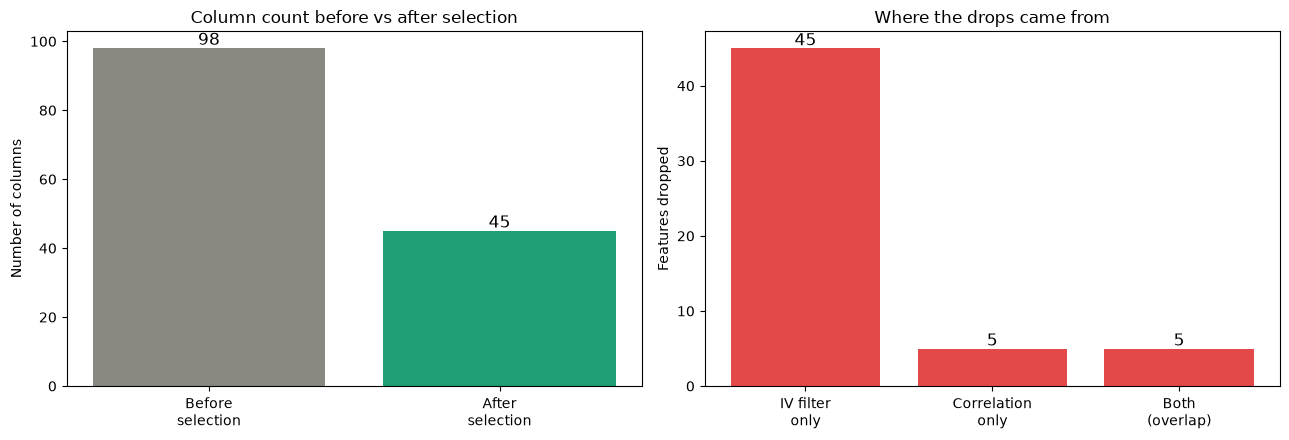

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].bar(['Before\nselection', 'After\nselection'],
                   [98, df_selected.shape[1]], color=[C_GREY, C_GREEN])
for b, v in zip(bars, [98, df_selected.shape[1]]):
    axes[0].text(b.get_x() + b.get_width()/2, v + 1, str(v), ha='center', fontsize=12)
axes[0].set_ylabel('Number of columns')
axes[0].set_title('Column count before vs after selection')

iv_only  = len([f for f in candidates_below_cutoff if f not in correlation_drops])
corr_only = len([f for f in correlation_drops if f not in candidates_below_cutoff])
overlap  = len(set(candidates_below_cutoff) & set(correlation_drops))
bars = axes[1].bar(['IV filter\nonly', 'Correlation\nonly', 'Both\n(overlap)'],
                   [iv_only, corr_only, overlap], color=C_RED)
for b, v in zip(bars, [iv_only, corr_only, overlap]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.4, str(v), ha='center', fontsize=12)
axes[1].set_ylabel('Features dropped')
axes[1].set_title('Where the drops came from')

save_show("04_selection_summary.png")

## 4.5 Layer 3 — Mutual Information cross-check

IV and correlation both have blind spots. MI measures *any* statistical
dependency (linear or not), so it serves as an independent second opinion on
the surviving features — computed on training rows only, with train-only
median imputation for the calculation.

                    feature  MI_score
            FLAG_DOCUMENT_3      0.05
           HAS_LATE_PAYMENT      0.03
        NAME_EDUCATION_TYPE      0.03
           HAS_UNDERPAYMENT      0.02
           NAME_INCOME_TYPE      0.02
REGION_RATING_CLIENT_W_CITY      0.02
            EXT_SOURCE_MEAN      0.02
                OWN_CAR_AGE      0.02
                CREDIT_TERM      0.02
               EXT_SOURCE_1      0.02
                CODE_GENDER      0.02
          HAS_PRIOR_REFUSAL      0.02
               EXT_SOURCE_3      0.02
         NAME_FAMILY_STATUS      0.01
             EXT_SOURCE_SUM      0.01


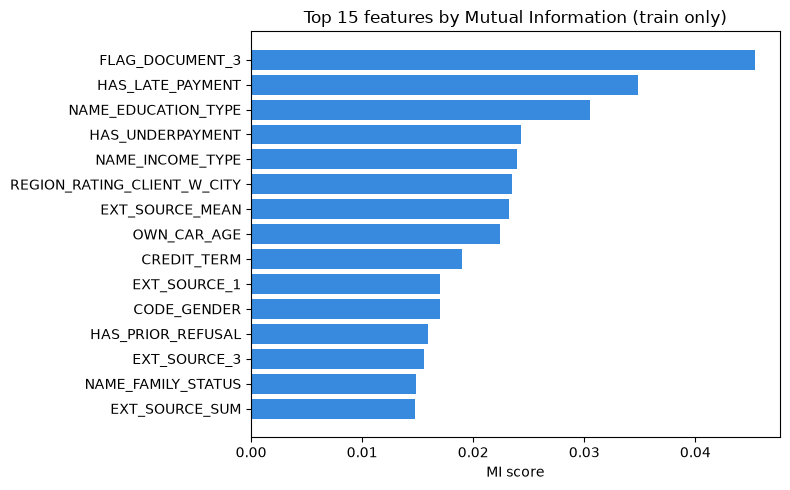

In [14]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

df_mi = df_selected.loc[train_idx].drop(columns=exclude_cols).copy()

for col in df_mi.columns:
    if is_text_column(df_mi[col]):
        df_mi[col] = LabelEncoder().fit_transform(df_mi[col].astype(str))

df_mi = df_mi.fillna(df_mi.median(numeric_only=True))

mi_scores = mutual_info_classif(df_mi, df_selected.loc[train_idx, 'TARGET'],
                                random_state=RANDOM_STATE)
mi_df = (pd.DataFrame({'feature': df_mi.columns, 'MI_score': mi_scores})
         .sort_values('MI_score', ascending=False).reset_index(drop=True))
print(mi_df.head(15).to_string(index=False))

barh_topn(mi_df.head(15).sort_values('MI_score').set_index('feature')['MI_score'],
          title='Top 15 features by Mutual Information (train only)',
          xlabel='MI score', color=C_BLUE, fig_name='04_mutual_information.png')

**Cross-check verdict.** The MI ranking broadly agrees with IV on the top
features (`EXT_SOURCE_*`, `CREDIT_TERM`, occupation/organisation), which is
what independent methods agreeing looks like. Features that IV liked but MI
ranks low (or vice versa) are noted, not acted on — final arbitration belongs
to the models themselves via SHAP in Stage 10.

## 4.6 Layer 4 — VIF and the Logistic-Regression-specific set

Pairwise correlation misses **multi-feature** redundancy: a feature predictable
from a *combination* of others. VIF_i = 1/(1−R²_i) catches it. VIF > 10 is the
standard concern threshold — and it matters specifically for **linear models**;
trees simply pick one of the redundant twins per split.

                    feature    VIF
            EXT_SOURCE_MEAN 143.08
   CREDIT_GOODS_PRICE_RATIO  94.29
               EXT_SOURCE_2  51.21
               EXT_SOURCE_3  41.30
                 DAYS_BIRTH  33.34
               EXT_SOURCE_1  32.24
                AMT_ANNUITY  23.17
REGION_RATING_CLIENT_W_CITY  23.16
            AMT_GOODS_PRICE  18.66
                CREDIT_TERM  17.54
             EXT_SOURCE_SUM  15.77
           HAS_LATE_PAYMENT   5.62
            DAYS_ID_PUBLISH   5.55
           HAS_UNDERPAYMENT   4.47
 REGION_POPULATION_RELATIVE   4.42

Features with VIF > 10: 11


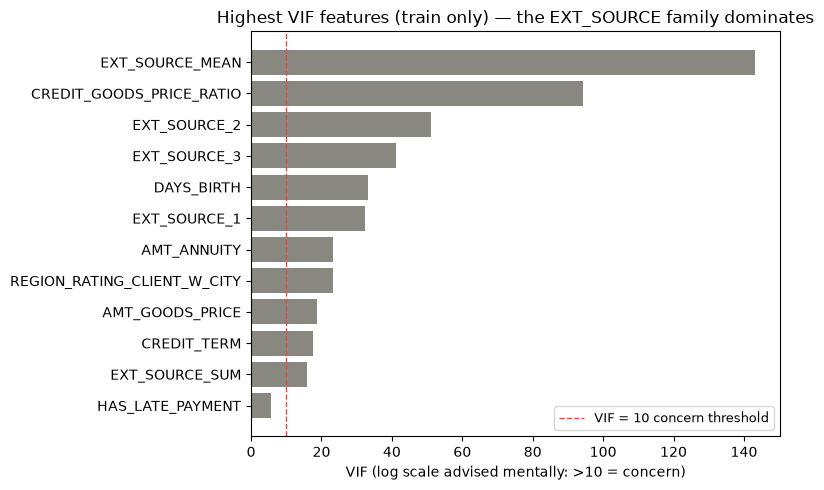

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_selected = (df_selected.loc[train_idx]
                    .select_dtypes(include=[np.number])
                    .drop(columns=exclude_cols))
numeric_clean = numeric_selected.fillna(numeric_selected.median())

vif_data = pd.DataFrame({
    'feature': numeric_clean.columns,
    'VIF': [variance_inflation_factor(numeric_clean.values, i)
            for i in range(numeric_clean.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_data.head(15).to_string(index=False))
print(f"\nFeatures with VIF > 10: {(vif_data['VIF'] > 10).sum()}")

top_vif = vif_data.head(12).sort_values('VIF').set_index('feature')['VIF']
barh_topn(top_vif, title='Highest VIF features (train only) — the EXT_SOURCE family dominates',
          xlabel='VIF (log scale advised mentally: >10 = concern)',
          color=C_GREY, vline=10, vline_label='VIF = 10 concern threshold',
          fig_name='04_vif.png')

**Expected collinearity, by construction.** The EXT_SOURCE family dominates —
`EXT_SOURCE_MEAN` and `SUM` are literally linear combinations of the three
individual scores, so extreme VIF is guaranteed. The fix is model-specific,
per the blueprint:

- **Tree models** keep the full general set (multicollinearity muddies tree
  *importance attribution* but not predictions).
- **Logistic Regression** drops `EXT_SOURCE_SUM`, `EXT_SOURCE_1/2/3`, keeping
  only `EXT_SOURCE_MEAN` — by far the highest-IV member of the family — so its
  coefficients stay stable and interpretable (essential for the scorecard role).

In [16]:
vif_drop_for_lr = ['EXT_SOURCE_SUM', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
df_selected_lr = df_selected.drop(columns=[c for c in vif_drop_for_lr
                                           if c in df_selected.columns])
print(f"LR set: {df_selected.shape[1]} -> {df_selected_lr.shape[1]} columns")

LR set: 45 -> 41 columns


## 4.7 Save outputs

In [17]:
df_selected.to_csv(DATA_PATH + "features_selected_general.csv", index=False)
df_selected_lr.to_csv(DATA_PATH + "features_selected_lr.csv", index=False)

print(f"features_selected_general.csv : {df_selected.shape}  (tree models)")
print(f"features_selected_lr.csv      : {df_selected_lr.shape}  (Logistic Regression)")
print(f"train_test_split_ids.csv      : frozen 80/20 split (saved in section 4.1)")

# Full audit trail of every decision this notebook made
iv_df[['feature', 'IV']].to_csv(DATA_PATH + "iv_scores_train.csv", index=False)
print(f"iv_scores_train.csv           : IV audit trail ({len(iv_df)} features)")

features_selected_general.csv : (307511, 45)  (tree models)
features_selected_lr.csv      : (307511, 41)  (Logistic Regression)
train_test_split_ids.csv      : frozen 80/20 split (saved in section 4.1)
iv_scores_train.csv           : IV audit trail (96 features)


---
# Summary

| Layer | Statistic (train-only) | Action |
|---|---|---|
| 1 — IV | optimal-binning Information Value | drop < 0.02, with 2 evidence-protected exceptions |
| 2 — Correlation | pairwise > 0.85 | keep higher-IV member; 1 documented override (DAYS_BIRTH over AGE_INT) |
| 3 — MI | non-linear dependency | cross-check only — agreement confirmed, no drops |
| 4 — VIF | multi-feature collinearity | LR-specific: EXT family reduced to EXT_SOURCE_MEAN |

**Leakage discipline:** the 80/20 split was created *before* any selection
statistic was computed, every statistic used training rows only, and the split
is frozen to `train_test_split_ids.csv` — notebook 05 loads it rather than
re-splitting, so the test set's labels have influenced nothing.

Two judgment calls are recorded with their evidence: the protected overdue
flags (real signal, metric limitation) versus `NAME_HOUSING_TYPE` (real
gradient, genuinely low population-level information) — opposite verdicts,
same investigative method.

## Next: Notebook 05 — model pipelines & training
Four models with model-specific preprocessing, trained on the frozen split;
XGBoost tuned with Optuna using **cross-validation inside the objective**
(the test set is never touched during tuning).